# Unsupervised Customer Segmentation using K-Means Clustering

**Objective:** Apply K-Means clustering on customer profile features, visualize clusters using PCA, and assign business-friendly segment labels.

## 1. Import Libraries and Load Data

The dataset contains customer support tickets. We will create customer-level features from available profile and support behaviour fields.

In [15]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

data_path = "../data/processed/customer_support_tickets.parquet"

df = pd.read_parquet(data_path)

df.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,None,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,None,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 2. Feature Engineering

K-Means requires numerical features. We create customer profile and behaviour features:

- Age
- Satisfaction rating
- Response time
- Resolution time
- Ticket count
- Priority/status/channel based encoded behaviour

In [16]:
# Convert time columns into useful numeric features

df['First Response Time'] = pd.to_datetime(df['First Response Time'])
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'])

# Duration features if available
df['first_response_hour'] = pd.to_datetime(
    df['First Response Time']
).dt.hour

df['resolution_hour'] = pd.to_datetime(
    df['Time to Resolution']
).dt.hour

df[['first_response_hour','resolution_hour']].describe()


,first_response_hour,resolution_hour
count,5650.000000,2769.000000
mean,11.524602,11.470928
std,6.965269,6.860077
min,0.000000,0.000000
25%,5.000000,6.000000
50%,11.000000,11.000000
75%,18.000000,17.000000
max,23.000000,23.000000


In [17]:
# Aggregate ticket data at customer level

customer_df = df.groupby('Customer Name').agg(
    Age=('Customer Age','first'),
    Satisfaction=('Customer Satisfaction Rating','mean'),
    Ticket_Count=('Ticket ID','count'),
    Avg_Response_Hours=('first_response_hour','mean'),
    Avg_Resolution_Hours=('resolution_hour','mean'),
    High_Priority_Tickets=('Ticket Priority', lambda x: (x=='High').sum())
).reset_index()

customer_df.head()


,Customer Name,Age,Satisfaction,Ticket_Count,Avg_Response_Hours,Avg_Resolution_Hours,High_Priority_Tickets
0,Aaron Abbott,59,NaN,1,NaN,NaN,0
1,Aaron Adams,53,NaN,1,NaN,NaN,0
2,Aaron Aguilar,25,4.0,1,18.0,17.0,0
3,Aaron Brown,28,NaN,1,NaN,NaN,0
4,Aaron Carter,68,NaN,1,NaN,NaN,1


## 3. Prepare Data for Clustering

Scaling is required because K-Means uses distance calculations.

In [18]:
features = customer_df.drop(columns=['Customer Name'])

features = features.fillna(features.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

X_scaled.shape


(8028, 6)

## 4. Select Number of Clusters

Silhouette score is used to find a suitable cluster count.

In [19]:
scores = {}

for k in range(2,9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

scores


{2: 0.279040962176418,
 3: 0.19078304505803353,
 4: 0.23751778845155358,
 5: 0.25050292626521664,
 6: 0.26322472860628254,
 7: 0.2627334745223142,
 8: 0.2821498643464326}

In [20]:
best_k = max(scores, key=scores.get)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_df['Cluster'] = kmeans.fit_predict(X_scaled)

customer_df['Cluster'].value_counts()


Cluster
3    1925
4    1843
1    1598
0     951
7     498
2     425
6     419
5     369
Name: count, dtype: int64

## 5. PCA Visualization

PCA reduces the feature space into two dimensions for visualization.

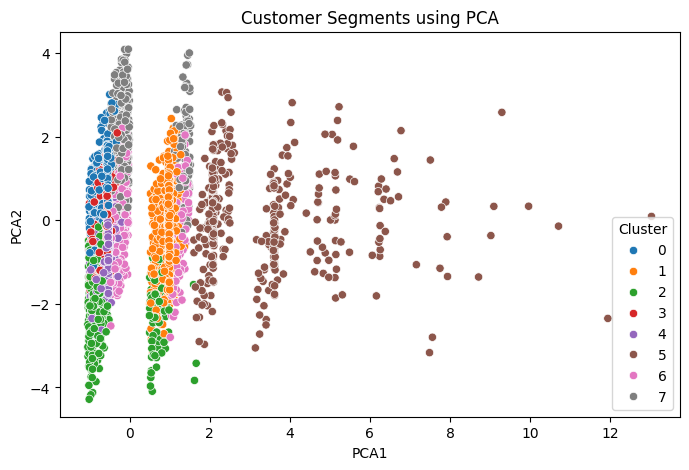

In [21]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

customer_df['PCA1'] = pca_data[:,0]
customer_df['PCA2'] = pca_data[:,1]

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=customer_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='tab10'
)

plt.title("Customer Segments using PCA")
plt.show()


## 6. Business Segment Profiling

Cluster averages are used to understand customer groups.

In [22]:
cluster_profile = customer_df.groupby('Cluster').mean(numeric_only=True)

cluster_profile


,Age,Satisfaction,Ticket_Count,Avg_Response_Hours,Avg_Resolution_Hours,High_Priority_Tickets,PCA1,PCA2
Cluster,,,,,,,,
0,44.613039,2.412162,1.000000,19.652997,7.625000,0.000000,-0.587065,0.869853
1,43.821652,2.344928,1.000000,11.607700,8.252174,1.000000,0.959265,-0.236494
2,42.484706,4.550588,1.007059,10.017647,4.647059,0.211765,-0.484208,-1.931058
3,57.327273,2.426471,1.000000,7.173077,8.610294,0.000000,-0.573992,0.180537
4,29.807379,2.411765,1.000000,7.788732,8.843137,0.000000,-0.550278,-0.494510
5,44.471545,2.978758,2.186992,11.530234,12.276144,0.509485,3.382122,0.042157
6,45.596659,4.565632,1.000000,11.565632,17.890215,0.267303,0.133471,0.014508
7,44.291165,1.738956,1.000000,11.963855,18.965863,0.194779,0.093077,1.834542


## 7. Assign Business Meaningful Labels

Labels are based on observed cluster characteristics. Review cluster_profile before final naming.

In [23]:
# Example mapping - modify after checking cluster_profile

segment_names = {
    0: "Low Engagement Customers",
    1: "High Value Satisfied Customers",
    2: "Frequent Support Users"
}

customer_df['Segment'] = customer_df['Cluster'].map(segment_names)

customer_df[['Customer Name','Cluster','Segment']].head()


,Customer Name,Cluster,Segment
0,Aaron Abbott,3,NaN
1,Aaron Adams,3,NaN
2,Aaron Aguilar,6,NaN
3,Aaron Brown,4,NaN
4,Aaron Carter,1,High Value Satisfied Customers


## 8. Save Final Segmentation Output

The final dataset contains customers with assigned segments.

In [24]:
customer_df.to_csv("../customer_segments.csv", index=False)

customer_df.head()


,Customer Name,Age,Satisfaction,Ticket_Count,Avg_Response_Hours,Avg_Resolution_Hours,High_Priority_Tickets,Cluster,PCA1,PCA2,Segment
0,Aaron Abbott,59,NaN,1,NaN,NaN,0,3,-0.560820,0.425486,NaN
1,Aaron Adams,53,NaN,1,NaN,NaN,0,3,-0.556038,0.271667,NaN
2,Aaron Aguilar,25,4.0,1,18.0,17.0,0,6,-0.288208,0.431655,NaN
3,Aaron Brown,28,NaN,1,NaN,NaN,0,4,-0.536109,-0.369242,NaN
4,Aaron Carter,68,NaN,1,NaN,NaN,1,1,0.963445,0.361694,High Value Satisfied Customers
